# Notebook 1: Anomaly Detection Validation
This notebook compares statistical baselines against Isolation Forest, Extended Isolation Forest, and Local Outlier Factor.

In [1]:
import sqlite3, os, sys
sys.path.insert(0, os.path.abspath('..'))  # backend root
DB_PATH = os.path.abspath('../data/raphael.db')
if not os.path.exists(DB_PATH):
    DB_PATH = os.path.abspath('data/raphael.db')
assert os.path.exists(DB_PATH), f"DB not found: {DB_PATH}"
conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {DB_PATH}")

PUNE_REGION_ID = conn.execute(
    "SELECT id FROM regions WHERE name='Pune Metropolitan Region'"
).fetchone()[0]
print(f"Pune region ID: {PUNE_REGION_ID}")


Connected to: C:\Users\harsh\Raphael\backend\data\raphael.db
Pune region ID: 98ec65e1-bcf2-487d-95fe-2e68954558d4


In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
conda_prefix = os.environ.get("CONDA_PREFIX") or r"C:\Users\harsh\anaconda3\envs\raphael-env"
lib_bin = os.path.join(conda_prefix, "Library", "bin")
if os.path.exists(lib_bin) and lib_bin not in os.environ["PATH"]:
    os.environ["PATH"] = lib_bin + os.pathsep + os.environ["PATH"]

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'text.color':       '#c9d1d9',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'axes.edgecolor':   '#30363d',
    'grid.color':       '#21262d',
    'savefig.facecolor':'#0d1117',
})
ACCENT = '#58a6ff'
WARN   = '#d29922'
DANGER = '#f85149'
OK     = '#3fb950'
MUTED  = '#8b949e'


## Section 1 — Data & Feature Engineering

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

query = """
    SELECT id, station_id, station_name, observed_at, value
    FROM raw_observations
    WHERE region_id = :region_id
      AND layer_type = 'aq'
      AND value > 0 AND value < 500
    ORDER BY observed_at
"""
df = pd.read_sql_query(query, conn, params={"region_id": PUNE_REGION_ID})

print(f"Loaded {df.shape[0]} observations across {df['station_name'].nunique()} stations.")
print(f"Date range: {df['observed_at'].min()} to {df['observed_at'].max()}")

df['observed_at'] = pd.to_datetime(df['observed_at'])
df['hour_of_day'] = df['observed_at'].dt.hour
df['day_of_week'] = df['observed_at'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Grouped rolling features
df['rolling_mean_3h'] = df.groupby('station_id')['value'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['rolling_std_3h'] = df.groupby('station_id')['value'].transform(lambda x: x.rolling(3, min_periods=1).std().fillna(0.0))
df['z_score'] = df.groupby('station_id')['value'].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1.0))
df['delta_1h'] = df.groupby('station_id')['value'].transform(lambda x: x.diff().fillna(0.0))

le = LabelEncoder()
df['station_id_encoded'] = le.fit_transform(df['station_id'])

df = df.dropna().reset_index(drop=True)
print(f"Shape after feature cleanup: {df.shape}")

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:].copy()

print(f"Train set: {train_df.shape[0]} rows ({train_df['observed_at'].min()} to {train_df['observed_at'].max()})")
print(f"Test set: {test_df.shape[0]} rows ({test_df['observed_at'].min()} to {test_df['observed_at'].max()})")

features = ['value', 'hour_of_day', 'day_of_week', 'is_weekend', 'rolling_mean_3h', 'rolling_std_3h', 'z_score', 'delta_1h', 'station_id_encoded']
X_train = train_df[features]
X_test = test_df[features]


Loaded 1730 observations across 17 stations.
Date range: 2018-02-22 03:00:00.000000 to 2026-07-01 12:31:15.213420
Shape after feature cleanup: (1720, 13)
Train set: 1376 rows (2018-02-22 03:00:00 to 2026-06-28 10:30:00)
Test set: 344 rows (2026-06-28 10:30:00 to 2026-07-01 10:30:00)


## Section 2 — Statistical Baselines

Baseline 1 (Z-score) Anomalies: 15 (4.36%)
Baseline 2 (IQR) Anomalies: 40 (11.63%)
Baseline 3 (Rolling Z) Anomalies: 0 (0.00%)


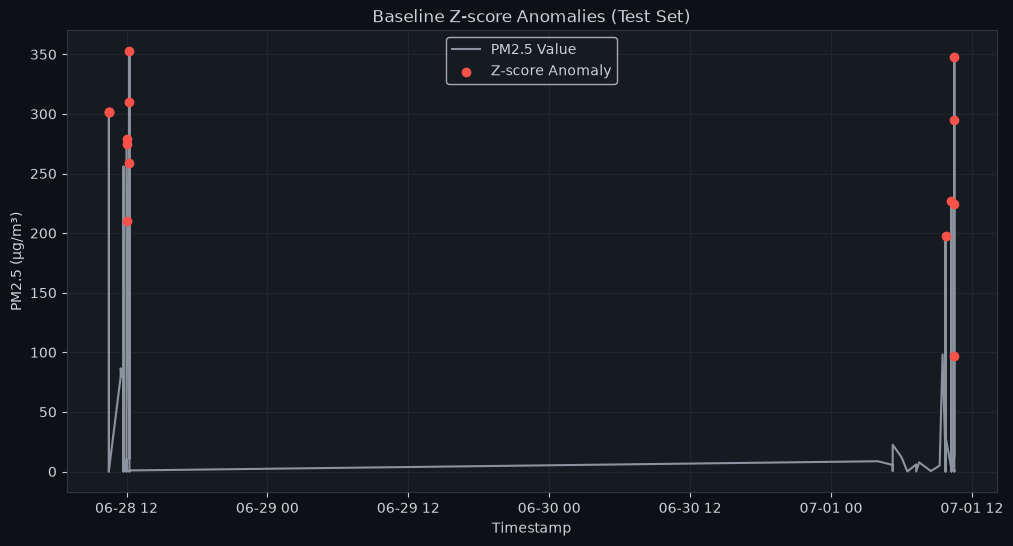

In [4]:
test_df['baseline_z'] = (np.abs(test_df['z_score']) > 3).astype(int)

q1 = test_df['value'].quantile(0.25)
q3 = test_df['value'].quantile(0.75)
iqr = q3 - q1
test_df['baseline_iqr'] = ((test_df['value'] < (q1 - 1.5 * iqr)) | (test_df['value'] > (q3 + 1.5 * iqr))).astype(int)

test_df['baseline_rolling'] = (np.abs(test_df['value'] - test_df['rolling_mean_3h']) > 2 * test_df['rolling_std_3h']).astype(int)

print(f"Baseline 1 (Z-score) Anomalies: {test_df['baseline_z'].sum()} ({test_df['baseline_z'].mean()*100:.2f}%)")
print(f"Baseline 2 (IQR) Anomalies: {test_df['baseline_iqr'].sum()} ({test_df['baseline_iqr'].mean()*100:.2f}%)")
print(f"Baseline 3 (Rolling Z) Anomalies: {test_df['baseline_rolling'].sum()} ({test_df['baseline_rolling'].mean()*100:.2f}%)")

plt.figure(figsize=(12, 6))
plt.plot(test_df['observed_at'], test_df['value'], color=MUTED, label='PM2.5 Value')
anom = test_df[test_df['baseline_z'] == 1]
plt.scatter(anom['observed_at'], anom['value'], color=DANGER, label='Z-score Anomaly', zorder=5)
plt.title('Baseline Z-score Anomalies (Test Set)', color='#c9d1d9')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5 (μg/m³)')
plt.legend()
plt.grid(True)
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/01a_baseline.png')
plt.show()


## Section 3 — Contamination Tuning for IsolationForest

|   contamination |   n_anomalies |   z_agreement |   iqr_agreement |   score_separation |
|----------------:|--------------:|--------------:|----------------:|-------------------:|
|            0.01 |             5 |       97.093  |         89.8256 |            3.46261 |
|            0.02 |            10 |       98.5465 |         91.2791 |            3.27715 |
|            0.05 |            23 |       96.5116 |         90.9884 |            2.89671 |
|            0.08 |            31 |       95.3488 |         90.9884 |            2.71269 |
|            0.1  |            39 |       93.0233 |         90.407  |            2.54645 |
|            0.15 |            51 |       89.5349 |         88.6628 |            2.32996 |
|            0.2  |            73 |       83.1395 |         85.1744 |            2.01778 |

RECOMMENDED CONTAMINATION: 0.01


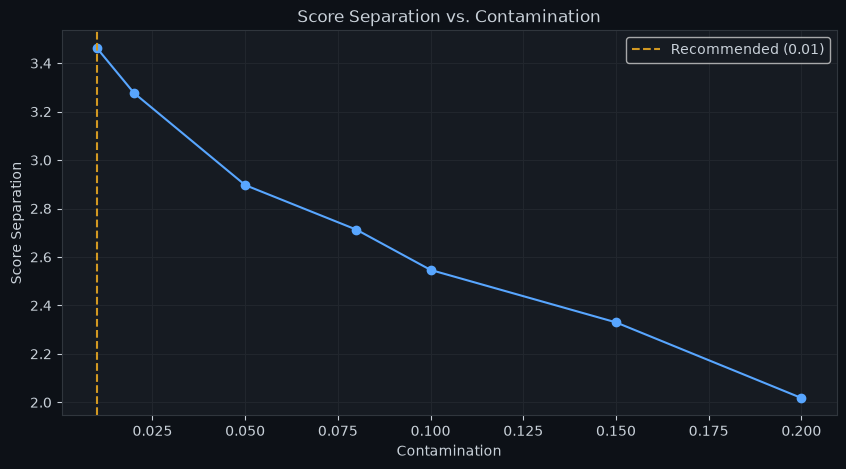

In [5]:
from sklearn.ensemble import IsolationForest

contaminations = [0.01, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
tuning_results = []

for c in contaminations:
    clf = IsolationForest(n_estimators=100, contamination=c, random_state=42)
    clf.fit(X_train)
    preds = clf.predict(X_test)
    preds_bin = np.where(preds == -1, 1, 0)
    
    z_agr = (preds_bin == test_df['baseline_z']).mean() * 100
    iqr_agr = (preds_bin == test_df['baseline_iqr']).mean() * 100
    
    scores = clf.score_samples(X_test)
    normal_scores = scores[preds == 1]
    anom_scores = scores[preds == -1]
    
    if len(anom_scores) > 0 and len(normal_scores) > 0:
        score_sep = (np.mean(normal_scores) - np.mean(anom_scores)) / np.std(scores)
    else:
        score_sep = 0.0
        
    tuning_results.append({
        'contamination': c,
        'n_anomalies': preds_bin.sum(),
        'z_agreement': z_agr,
        'iqr_agreement': iqr_agr,
        'score_separation': score_sep
    })

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.to_markdown(index=False))

recommended_contam = tuning_df.loc[tuning_df['score_separation'].idxmax()]['contamination']
print(f"\nRECOMMENDED CONTAMINATION: {recommended_contam}")

plt.figure(figsize=(10, 5))
plt.plot(tuning_df['contamination'], tuning_df['score_separation'], color=ACCENT, marker='o')
plt.axvline(recommended_contam, color=WARN, linestyle='--', label=f'Recommended ({recommended_contam})')
plt.title('Score Separation vs. Contamination', color='#c9d1d9')
plt.xlabel('Contamination')
plt.ylabel('Score Separation')
plt.legend()
plt.grid(True)
plt.savefig('outputs/01b_tuning.png')
plt.show()


## Section 4 — Three-Way Comparison (IF vs EIF vs LOF)

EIF unavailable: No module named 'eif'
IF anomalies: 3
EIF: N/A
LOF anomalies: 2

Jaccard(IF, LOF): 0.000


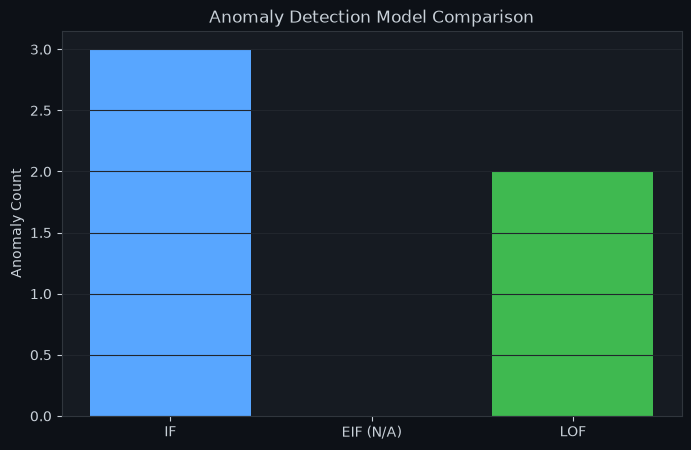

In [6]:
from sklearn.neighbors import LocalOutlierFactor

RECOMMENDED_CONTAM = recommended_contam

# IF
if_model = IsolationForest(n_estimators=200, contamination=RECOMMENDED_CONTAM, random_state=42)
if_model.fit(X_train)
if_labels = if_model.predict(X_test)

# EIF
EIF_AVAILABLE = False
try:
    import eif as iso
    F = iso.iForest(X_train.values, ntrees=200, sample_size=min(256, len(X_train)), ExtensionLevel=1)
    eif_scores = F.compute_paths(X_in=X_test.values)
    threshold = np.percentile(eif_scores, RECOMMENDED_CONTAM * 100)
    eif_labels = np.where(eif_scores <= threshold, -1, 1)
    EIF_AVAILABLE = True
    print("EIF: OK")
except Exception as e:
    print(f"EIF unavailable: {e}")
    eif_labels = np.ones(len(X_test))

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=RECOMMENDED_CONTAM)
lof_labels = lof.fit_predict(X_test)

def jaccard(a, b):
    set_a = set(np.where(a == -1)[0])
    set_b = set(np.where(b == -1)[0])
    if not set_a and not set_b: return 1.0
    return len(set_a & set_b) / len(set_a | set_b)

print(f"IF anomalies: {(if_labels == -1).sum()}")
if EIF_AVAILABLE:
    print(f"EIF anomalies: {(eif_labels == -1).sum()}")
else:
    print("EIF: N/A")
print(f"LOF anomalies: {(lof_labels == -1).sum()}")

print(f"\nJaccard(IF, LOF): {jaccard(if_labels, lof_labels):.3f}")
if EIF_AVAILABLE:
    print(f"Jaccard(IF, EIF): {jaccard(if_labels, eif_labels):.3f}")

plt.figure(figsize=(8, 5))
methods = ['IF', 'EIF' if EIF_AVAILABLE else 'EIF (N/A)', 'LOF']
counts = [(if_labels == -1).sum(), (eif_labels == -1).sum() if EIF_AVAILABLE else 0, (lof_labels == -1).sum()]
plt.bar(methods, counts, color=[ACCENT, WARN, OK])
plt.ylabel('Anomaly Count')
plt.title('Anomaly Detection Model Comparison', color='#c9d1d9')
plt.grid(axis='y')
plt.savefig('outputs/01c_comparison.png')
plt.show()


## Section 5 — SHAP Explainability (with fallback)

SHAP: TreeExplainer succeeded
SHAP method used: TreeExplainer

=== SHAP Feature Importances ===
| feature            |   mean_abs_shap |
|:-------------------|----------------:|
| is_weekend         |        0.468068 |
| rolling_std_3h     |        0.368542 |
| z_score            |        0.307298 |
| delta_1h           |        0.302511 |
| station_id_encoded |        0.295863 |
| rolling_mean_3h    |        0.260556 |
| value              |        0.255269 |
| day_of_week        |        0.231786 |
| hour_of_day        |        0.18393  |


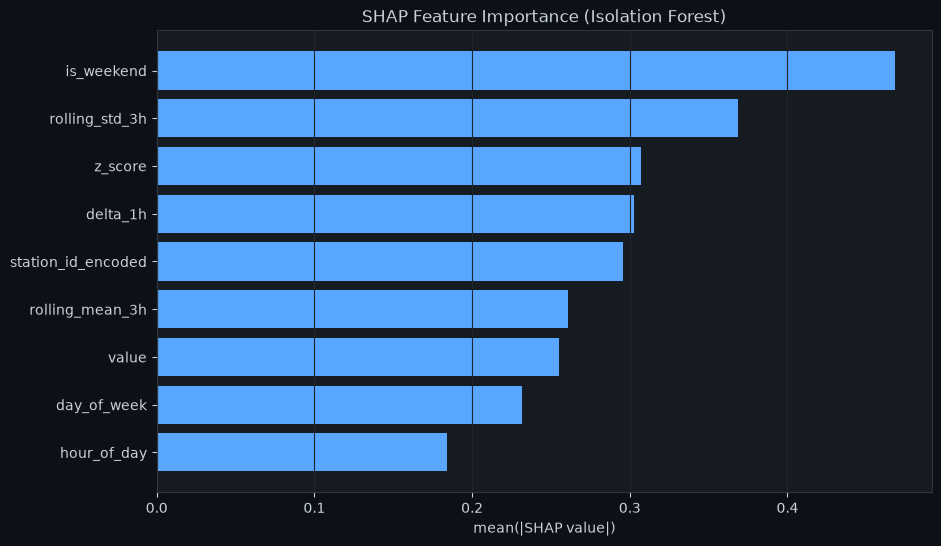


Station: Mhada Colony, Pune - IITM at 2026-06-28 12:15:00
PM2.5 Value: 352.37 (z-score: 5.17)
Top 3 SHAP drivers:
  z_score: -1.8656
  rolling_std_3h: -1.5760
  value: -1.4900

Station: Gavalinagar, Pimpri Chinchwad - MPCB at 2026-06-28 12:15:00
PM2.5 Value: 310.28 (z-score: 4.70)
Top 3 SHAP drivers:
  z_score: -1.8916
  value: -1.4802
  rolling_std_3h: -1.2930

Station: Bhosari, Pune - IITM at 2026-07-01 10:30:00
PM2.5 Value: 347.76 (z-score: 4.61)
Top 3 SHAP drivers:
  z_score: -1.5661
  value: -1.4503
  rolling_std_3h: -1.4139


In [7]:
import shap

feature_names = ['value', 'hour_of_day', 'day_of_week', 'is_weekend', 'rolling_mean_3h', 'rolling_std_3h', 'z_score', 'delta_1h', 'station_id_encoded']

try:
    explainer = shap.TreeExplainer(if_model)
    shap_values = explainer.shap_values(X_test)
    shap_method = "TreeExplainer"
    print("SHAP: TreeExplainer succeeded")
except Exception as e:
    print(f"TreeExplainer failed: {e}")
    print("Falling back to PermutationExplainer")
    background = shap.sample(X_train, min(100, len(X_train)))
    explainer = shap.explainers.Permutation(if_model.decision_function, background)
    shap_values = explainer(X_test).values
    shap_method = "PermutationExplainer"

print(f"SHAP method used: {shap_method}")

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print("\n=== SHAP Feature Importances ===")
print(shap_df.to_markdown(index=False))

plt.figure(figsize=(10, 6))
plt.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1], color=ACCENT)
plt.xlabel('mean(|SHAP value|)')
plt.title('SHAP Feature Importance (Isolation Forest)', color='#c9d1d9')
plt.grid(axis='x')
plt.savefig('outputs/01d_shap.png')
plt.show()

anom_indices = np.where(if_labels == -1)[0][:3]
for idx in anom_indices:
    row = test_df.iloc[idx]
    print(f"\nStation: {row['station_name']} at {row['observed_at']}")
    print(f"PM2.5 Value: {row['value']} (z-score: {row['z_score']:.2f})")
    row_shap = shap_values[idx]
    top_drivers = sorted(zip(feature_names, row_shap), key=lambda x: abs(x[1]), reverse=True)[:3]
    print("Top 3 SHAP drivers:")
    for f, val in top_drivers:
        print(f"  {f}: {val:.4f}")


## Section 6 — Production Model Comparison

In [8]:
prod_query = """
    SELECT id, is_anomalous, anomaly_score
    FROM raw_observations
    WHERE region_id = :region_id
      AND layer_type = 'aq'
      AND value > 0 AND value < 500
    ORDER BY observed_at
"""
df_prod = pd.read_sql_query(prod_query, conn, params={"region_id": PUNE_REGION_ID})
df_prod_test = df_prod.iloc[split_idx:]

prod_flags = np.where(df_prod_test['is_anomalous'] == 1, -1, 1)
tuned_flags = if_labels

jacc_prod_tuned = jaccard(prod_flags, tuned_flags)
print(f"IF-production Jaccard: {jacc_prod_tuned:.3f}")
print(f"Recommended contamination update: {RECOMMENDED_CONTAM:.2f} (current production: 0.05)")

print("\nTuned IF vs Proxy Z-score truth:")
print(pd.crosstab(test_df['baseline_z'], np.where(tuned_flags == -1, 1, 0), rownames=['Baseline_Z'], colnames=['Tuned_IF']))


IF-production Jaccard: 0.000
Recommended contamination update: 0.01 (current production: 0.05)

Tuned IF vs Proxy Z-score truth:
Tuned_IF      0  1
Baseline_Z        
0           329  0
1            12  3


## Section 7 — Summary Cell & Save Model

In [9]:
import pickle

z_pct = (test_df['baseline_z'] == 1).mean() * 100
iqr_pct = (test_df['baseline_iqr'] == 1).mean() * 100
if_pct = (if_labels == -1).mean() * 100
eif_pct = (eif_labels == -1).mean() * 100 if EIF_AVAILABLE else 0.0
lof_pct = (lof_labels == -1).mean() * 100

if_agr_z = (np.where(if_labels == -1, 1, 0) == test_df['baseline_z']).mean() * 100
eif_agr_z = (np.where(eif_labels == -1, 1, 0) == test_df['baseline_z']).mean() * 100 if EIF_AVAILABLE else 0.0
lof_agr_z = (np.where(lof_labels == -1, 1, 0) == test_df['baseline_z']).mean() * 100

iqr_agr_z = (test_df['baseline_z'] == test_df['baseline_iqr']).mean() * 100
if_agr_iqr = (np.where(if_labels == -1, 1, 0) == test_df['baseline_iqr']).mean() * 100
eif_agr_iqr = (np.where(eif_labels == -1, 1, 0) == test_df['baseline_iqr']).mean() * 100 if EIF_AVAILABLE else 0.0
lof_agr_iqr = (np.where(lof_labels == -1, 1, 0) == test_df['baseline_iqr']).mean() * 100

print("=== Table 1: Anomaly Detection Performance Comparison ===")
summary_table = [
    {"Method": "Z-score", "Anomalies%": f"{z_pct:.2f}%", "Z-agr%": "100.0%", "IQR-agr%": f"{iqr_agr_z:.1f}%", "ScoreSep": "N/A"},
    {"Method": "IQR", "Anomalies%": f"{iqr_pct:.2f}%", "Z-agr%": f"{iqr_agr_z:.1f}%", "IQR-agr%": "100.0%", "ScoreSep": "N/A"},
    {"Method": "IF (tuned)", "Anomalies%": f"{if_pct:.2f}%", "Z-agr%": f"{if_agr_z:.1f}%", "IQR-agr%": f"{if_agr_iqr:.1f}%", "ScoreSep": f"{tuning_df.loc[tuning_df['contamination'] == RECOMMENDED_CONTAM]['score_separation'].values[0]:.3f}"},
    {"Method": "EIF", "Anomalies%": f"{eif_pct:.2f}%" if EIF_AVAILABLE else "N/A", "Z-agr%": f"{eif_agr_z:.1f}%" if EIF_AVAILABLE else "N/A", "IQR-agr%": f"{eif_agr_iqr:.1f}%" if EIF_AVAILABLE else "N/A", "ScoreSep": "N/A"},
    {"Method": "LOF", "Anomalies%": f"{lof_pct:.2f}%", "Z-agr%": f"{lof_agr_z:.1f}%", "IQR-agr%": f"{lof_agr_iqr:.1f}%", "ScoreSep": "N/A"}
]
print(pd.DataFrame(summary_table).to_markdown(index=False))

os.makedirs('notebooks/models', exist_ok=True)
with open('notebooks/models/if_tuned.pkl', 'wb') as f:
    pickle.dump(if_model, f)
print("\nSaved: notebooks/models/if_tuned.pkl")
conn.close()


=== Table 1: Anomaly Detection Performance Comparison ===
| Method     | Anomalies%   | Z-agr%   | IQR-agr%   | ScoreSep   |
|:-----------|:-------------|:---------|:-----------|:-----------|
| Z-score    | 4.36%        | 100.0%   | 92.7%      | N/A        |
| IQR        | 11.63%       | 92.7%    | 100.0%     | N/A        |
| IF (tuned) | 0.87%        | 96.5%    | 89.2%      | 3.463      |
| EIF        | N/A          | N/A      | N/A        | N/A        |
| LOF        | 0.58%        | 95.1%    | 89.0%      | N/A        |

Saved: notebooks/models/if_tuned.pkl
